In [3]:
# This imports all the libraries we need
# Think of this like opening all your toolboxes before starting work

import pandas as pd          # for loading and working with data
import numpy as np           # for math operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # for better-looking charts
from sklearn.model_selection import train_test_split  # splits data for ML
from sklearn.linear_model import LogisticRegression   # prediction model
from sklearn.metrics import accuracy_score, classification_report

# This makes charts look nicer
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# pd.read_csv() reads your CSV file into a "DataFrame"
# A DataFrame is like an Excel table in Python

df = pd.read_csv('../data/churn_data.csv')

# .shape tells you rows and columns
print(f"Dataset size: {df.shape[0]} rows, {df.shape[1]} columns")

# .head() shows you the first 5 rows
df.head()

Dataset size: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# .info() shows column names, data types, and missing values
print("=== DATASET INFORMATION ===")
df.info()

print("\n=== FIRST LOOK AT CHURN COLUMN ===")
print(df['Churn'].value_counts())

# What % of customers churned?
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"\nChurn Rate: {churn_rate:.1f}%")

=== DATASET INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 no

In [7]:
# TotalCharges column has some empty values — we need to fix this
# pd.to_numeric converts text numbers to actual numbers
# errors='coerce' turns any bad value into NaN (blank)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is blank (only ~11 rows)
df = df.dropna(subset=['TotalCharges'])

# Convert Churn column: Yes=1, No=0 (needed for ML model later)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# Convert SeniorCitizen: make it Yes/No text for charts
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f"Clean dataset: {df.shape[0]} rows remaining")
print("Data cleaning complete!")

Clean dataset: 7032 rows remaining
Data cleaning complete!


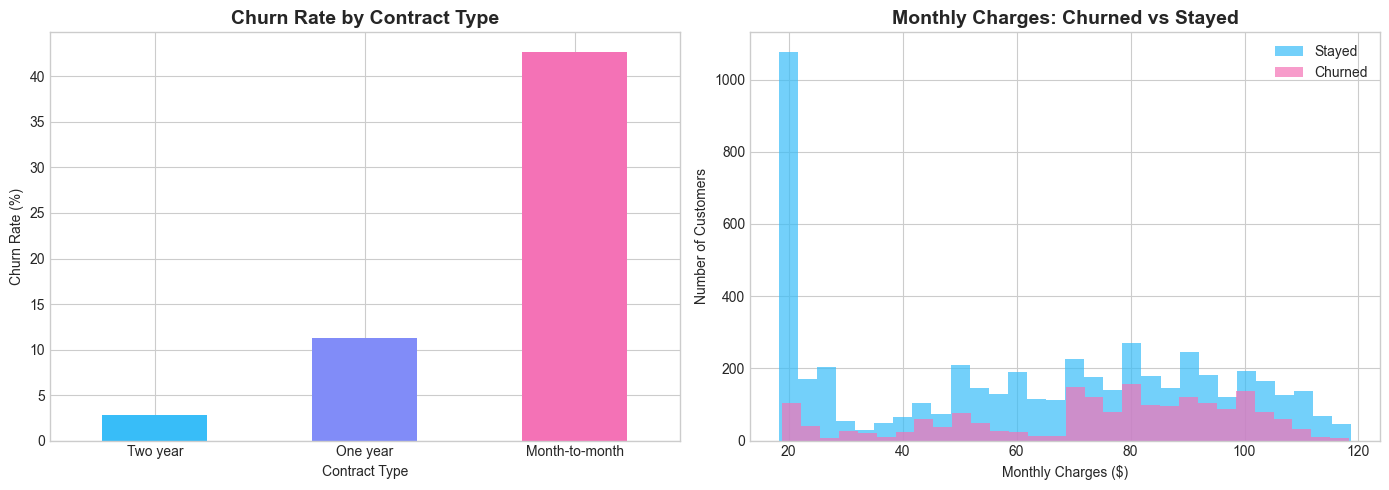

Chart saved!


In [8]:
# This chart shows which contract types have highest churn
# figsize=(10,5) sets chart width=10 inches, height=5 inches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
contract_churn.sort_values().plot(kind='bar', ax=axes[0], color=['#38bdf8', '#818cf8', '#f472b6'], edgecolor='none')
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Monthly Charges distribution for churned vs not
df[df['Churn']=='No']['MonthlyCharges'].hist(bins=30, alpha=0.7, ax=axes[1], label='Stayed', color='#38bdf8')
df[df['Churn']=='Yes']['MonthlyCharges'].hist(bins=30, alpha=0.7, ax=axes[1], label='Churned', color='#f472b6')
axes[1].set_title('Monthly Charges: Churned vs Stayed', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/churn_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

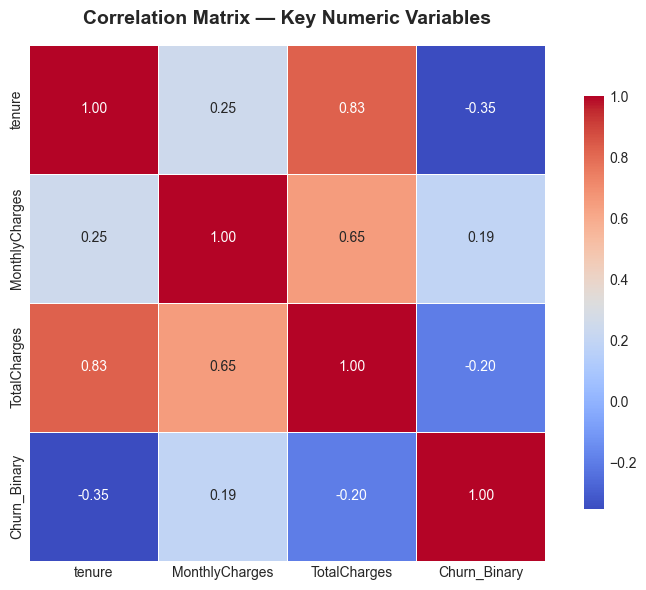

In [9]:
# A heatmap shows which numbers are related to each other
# Values close to 1 = strong positive relationship
# Values close to -1 = strong negative relationship

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Key Numeric Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# We'll build a Logistic Regression model
# This predicts "will this customer churn? Yes or No?"
# based on their contract type, charges, and tenure

# Step 1: Convert text columns to numbers (ML only works with numbers)
df_model = pd.get_dummies(df[['tenure', 'MonthlyCharges', 'TotalCharges',
                               'Contract', 'PaymentMethod', 'InternetService',
                               'Churn_Binary']], drop_first=True)

# Step 2: Split into features (X) and target (y)
X = df_model.drop('Churn_Binary', axis=1)  # everything except Churn
y = df_model['Churn_Binary']              # just the Churn column

# Step 3: Split into training data (80%) and testing data (20%)
# Training = model learns from this. Testing = we check how accurate it is
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Step 5: Test accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Model Accuracy: {accuracy:.1f}%")
print("\nDetailed Results:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Model Accuracy: 79.2%

Detailed Results:
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1033
     Churned       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# Power BI will import this cleaned Excel file
# We add a ChurnRisk column based on model predictions

df_export = df[['customerID', 'gender', 'SeniorCitizen_Label', 'tenure',
                'Contract', 'MonthlyCharges', 'TotalCharges',
                'InternetService', 'PaymentMethod', 'Churn', 'Churn_Binary']].copy()

df_export.to_excel('../data/churn_clean.xlsx', index=False)
print(f"Exported {len(df_export)} rows to churn_clean.xlsx")
print("Ready to import into Power BI!")

Exported 7032 rows to churn_clean.xlsx
Ready to import into Power BI!
